In [98]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp, shapiro, levene, ttest_ind, mannwhitneyu

In [99]:
excel_file = pd.ExcelFile("/Users/DELL/Downloads/ab_testing.xlsx")
print("Available sheet names:", excel_file.sheet_names)

Available sheet names: ['Control Group', 'Test Group']


In [100]:
df_control = pd.read_excel("/Users/DELL/Downloads/ab_testing.xlsx", 
                        sheet_name="Control Group")
df_control.head()

,Impression,Click,Purchase,Earning
0,82529.459271,6090.077317,665.211255,2311.277143
1,98050.451926,3382.861786,315.084895,1742.806855
2,82696.023549,4167.965750,458.083738,1797.827447
3,109914.400398,4910.882240,487.090773,1696.229178
4,108457.762630,5987.655811,441.034050,1543.720179


In [101]:
df_test = pd.read_excel("/Users/DELL/Downloads/ab_testing.xlsx",sheet_name= "Test Group")
df_test.head()

,Impression,Click,Purchase,Earning
0,120103.503796,3216.547958,702.160346,1939.611243
1,134775.943363,3635.082422,834.054286,2929.405820
2,107806.620788,3057.143560,422.934258,2526.244877
3,116445.275526,4650.473911,429.033535,2281.428574
4,145082.516838,5201.387724,749.860442,2781.697521


In [102]:
df_control.head()

,Impression,Click,Purchase,Earning
0,82529.459271,6090.077317,665.211255,2311.277143
1,98050.451926,3382.861786,315.084895,1742.806855
2,82696.023549,4167.965750,458.083738,1797.827447
3,109914.400398,4910.882240,487.090773,1696.229178
4,108457.762630,5987.655811,441.034050,1543.720179


In [103]:
df_control.shape

(40, 4)

In [104]:
df_test.shape

(40, 4)

In [205]:
print(type(df_control))
print(type(df_test))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


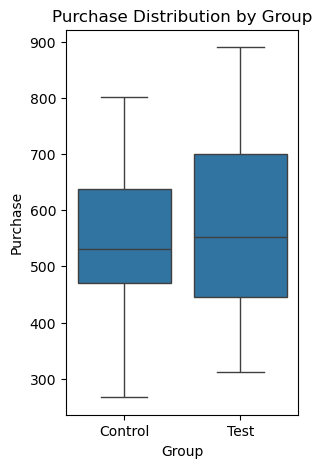

In [218]:
df_control["Group"] = "Control"
df_test["Group"] = "Test"

combined = pd.concat([df_control, df_test])

plt.figure(figsize=(3,5))
sns.boxplot(x="Group", y="Purchase", data=combined)

plt.title("Purchase Distribution by Group")
plt.show()

In [106]:
df_control['Purchase'].mean()

np.float64(550.8940587702316)

In [87]:
df_test['Purchase'].mean()

np.float64(582.1060966484677)

In [88]:
from scipy.stats import shapiro
test,p_value=shapiro(df_control["Purchase"])
print(f" test:{test:.4f}")
print(f" p_value:{p_value:.4f}")
test,p_value=shapiro(df_test["Purchase"])
print(f" test:{test:.4f}")
print(f" p_value:{p_value:.4f}")



 test:0.9773
 p_value:0.5891
 test:0.9589
 p_value:0.1541


In [89]:
test,p_value=levene(df_control["Purchase"],df_test["Purchase"])
print(f" test:{test:.4f}")
print(f" p_value:{p_value:.4f}")


 test:2.6393
 p_value:0.1083


In [96]:
test,p_value=ttest_ind(df_control["Purchase"],df_test["Purchase"])
print(f" test:{test:.4f}")
print(f" p_value:{p_value:.4f}")

 test:-0.9416
 p_value:0.3493


In [97]:
test,p_value=mannwhitneyu(df_control["Purchase"],df_test["Purchase"])
print(f" test:{test:.4f}")
print(f" p_value:{p_value:.4f}")

 test:723.0000
 p_value:0.4617


In [230]:
df_control_Impression=df_control["Impression"].sum()
df_control_Click=df_control["Click"].sum()
df_control_Purchase=df_control["Purchase"].sum()
print( "the sum of control impression is ",round(df_control_Impression,2))
print("the sum of control click is ",round(df_control_Click,2))
print("the sum of control purchase is ",round(df_control_Purchase,2))

the sum of control impression is  4068457.96
the sum of control click is  204026.29
the sum of control purchase is  22035.76


In [231]:
df_test_Impression=df_test["Impression"].sum()
df_test_Click=df_test["Click"].sum()
df_test_Purchase=df_test["Purchase"].sum()
print("the sum of test impression is ",round(df_test_Impression))
print("the sum of test click is ",round(df_test_Click))
print("the sum of test purchase is ",round(df_test_Purchase))

the sum of test impression is  4820496
the sum of test click is  158702
the sum of test purchase is  23284


In [237]:
ctr_control=(df_control_Click/df_control_Impression)*100
print("The CTR vaue of control is ",round(ctr_control,2))

The CTR vaue of control is  5.01


In [238]:
ctr_test=(df_test_Click/df_test_Impression)*100
print("The CTR vaue of test is ",round(ctr_test,2))

The CTR vaue of test is  3.29


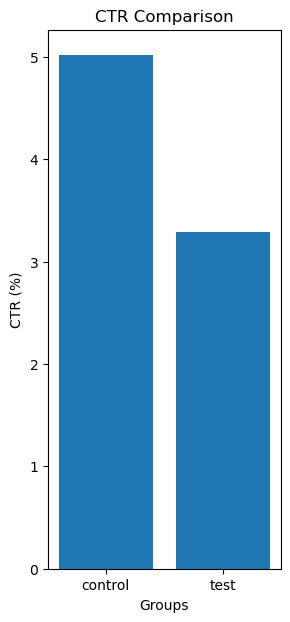

In [234]:
plt.figure(figsize=(3,7))
plt.bar(groups, ctr_values)
plt.title("CTR Comparison")
plt.ylabel("CTR (%)")
plt.xlabel("Groups")
plt.show()

In [239]:
cr_control=(df_control_Purchase/df_control_Click)*100
print("The CR value of control is ",round(cr_control,2))

The CR value of control is  10.8


In [240]:
cr_test=df_test_Purchase/df_test_Click*100
print("The CR value of test is ",round(cr_test,2))

The CR value of test is  14.67


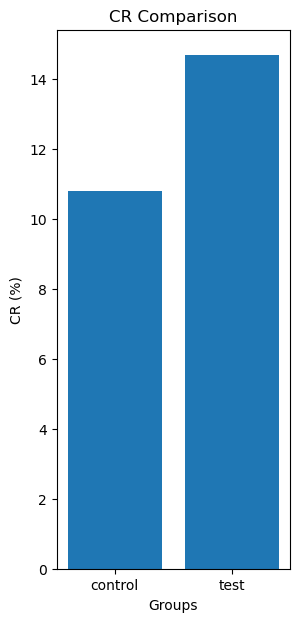

In [215]:
plt.figure(figsize=(3,7))
plt.bar(groups, cr_values)

plt.title("CR Comparison")
plt.ylabel("CR (%)")
plt.xlabel("Groups")
plt.show()

In [241]:
cr_lift=((cr_test-cr_control)/cr_control)*100
print("The CR lift percentage of control is ",round(cr_lift,2),"%")

The CR lift percentage is  35.84 %


In [242]:
ctr_lift=((ctr_test-ctr_control)/ctr_control)*100
print("The CR lift percentage of test is ",round(ctr_lift,2))

The CR lift percentage of test is  -34.35


In [243]:
groups =["control","test"]
ctr_values=[ctr_control,ctr_test]
cr_values=[cr_control,cr_test]

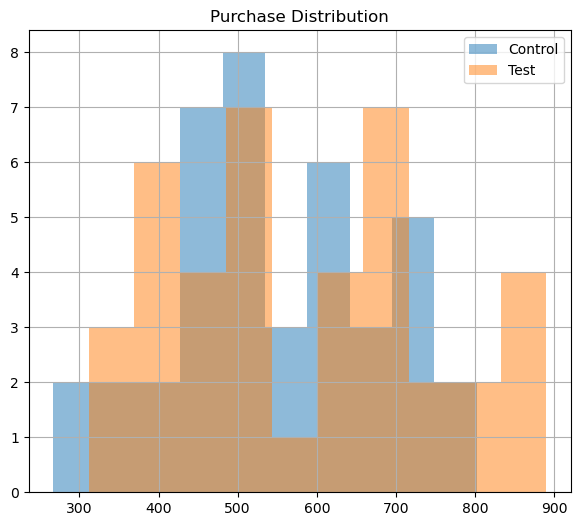

In [244]:
plt.figure(figsize=(7,6))

df_control["Purchase"].hist(alpha=0.5, label="Control")
df_test["Purchase"].hist(alpha=0.5, label="Test")

plt.legend()
plt.title("Purchase Distribution")
plt.show()